Loading metrics data...
Loaded 96 records

Sample data:
  test_type  mean_res       config  mean_waiting_time  total_energy_waste
0      easy         1    smart_t60         112.919478        5.211689e+06
1      easy         1  batsim_t480          22.735693        1.144262e+07
2      easy         2  batsim_t180         117.490216        1.864495e+07
3      easy         4  batsim_t600          55.802947        4.951476e+07
4      easy         8  batsim_t420         252.109392        7.679666e+07
Data with derived columns:
  test_type  mean_res       config timeout scheduler  mean_waiting_time  \
0      easy         1    smart_t60     t60     smart         112.919478   
1      easy         1  batsim_t480    t480    batsim          22.735693   
2      easy         2  batsim_t180    t180    batsim         117.490216   
3      easy         4  batsim_t600    t600    batsim          55.802947   
4      easy         8  batsim_t420    t420    batsim         252.109392   

   total_energy_waste 

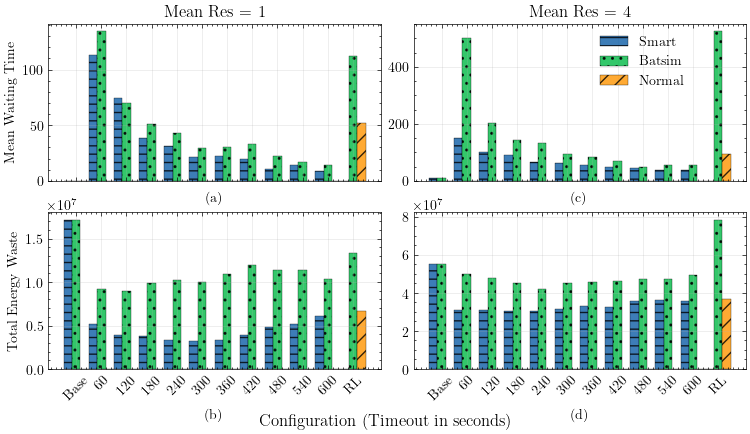


Generating super plot for baseline vs timeout 300
Processing baseline
Processing t300


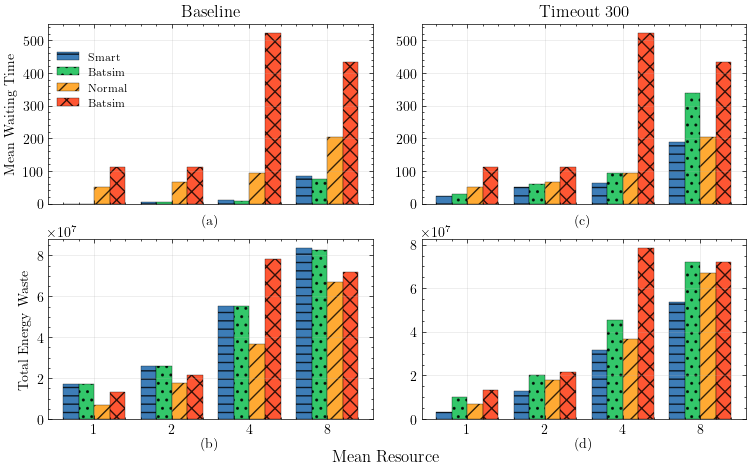

In [2]:
# %% [markdown]
# # Workshop Results Analysis
# 
# This notebook analyzes the workshop results by generating multiple charts comparing mean waiting time and wasted energy across different configurations.

# %%
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import os
import re
from pathlib import Path

# Set style for better looking plots
plt.style.use('science')
# plt.rcParams['figure.figsize'] = (12, 6)

# %%
# Configuration
RESULTS_DIR = "results"
MEAN_RES_VALUES = [1, 2, 4, 8]
TIMEOUT_VALUES = ['baseline', 't60', 't120', 't180', 't240', 't300', 't360', 't420', 't480', 't540', 't600']
RL_VALUES = ['normal', 'batsim']

# %%
def parse_directory_name(dir_name):
    """Parse directory name to extract configuration parameters"""
    pattern = r"workshop_(easy|rl)_test_(\d+)_\((.*?)\)"
    match = re.match(pattern, dir_name)
    
    if match:
        test_type = match.group(1)  # easy or rl
        mean_res = int(match.group(2))
        config = match.group(3)
        
        return test_type, mean_res, config
    return None, None, None

# %%
def load_all_metrics():
    """Load all metrics from the results directories"""
    data = []
    
    for dir_path in Path(RESULTS_DIR).iterdir():
        if dir_path.is_dir():
            test_type, mean_res, config = parse_directory_name(dir_path.name)
            
            if test_type is not None:
                metrics_file = dir_path / "metrics.csv"
                if metrics_file.exists():
                    try:
                        df = pd.read_csv(metrics_file)
                        if not df.empty:
                            row = df.iloc[0].to_dict()
                            row['test_type'] = test_type
                            row['mean_res'] = mean_res
                            row['config'] = config
                            data.append(row)
                    except Exception as e:
                        print(f"Error reading {metrics_file}: {e}")
    
    return pd.DataFrame(data)

# %%
# Load all data
print("Loading metrics data...")
df = load_all_metrics()
print(f"Loaded {len(df)} records")

# Display sample of the data
print("\nSample data:")
print(df[['test_type', 'mean_res', 'config', 'mean_waiting_time', 'total_energy_waste']].head())

# %%
def extract_timeout_value(config):
    """Extract timeout value from config string"""
    if config == 'smart_baseline' or config == 'batsim_baseline':
        return 'baseline'
    elif config.endswith('_baseline'):
        return 'baseline'
    elif config.startswith('smart_t') or config.startswith('batsim_t'):
        return config.split('_')[-1]  # Returns t60, t120, etc.
    elif config in ['normal', 'batsim']:
        return 'rl'
    return 'unknown'

def extract_scheduler_type(config):
    """Extract scheduler type from config string"""
    if config == 'normal':
        return 'normal'
    elif config == 'batsim':
        return 'batsim'
    elif config.startswith('smart'):
        return 'smart'
    elif config.startswith('batsim'):
        return 'batsim'
    return 'unknown'

# %%
# Add derived columns
df['timeout'] = df['config'].apply(extract_timeout_value)
df['scheduler'] = df['config'].apply(extract_scheduler_type)

print("Data with derived columns:")
print(df[['test_type', 'mean_res', 'config', 'timeout', 'scheduler', 'mean_waiting_time', 'total_energy_waste']].head())

# %% [markdown]
# ## Super Plot: Mean Resource 1 vs Mean Resource 4

# %%
# Create a super plot for mean_res 1 and mean_res 4
print("\nGenerating super plot for mean_res 1 and mean_res 4")

# Filter data for the two mean_res values we want
mean_res_values = [1, 4]
# colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

# Prepare x-axis categories
x_categories = TIMEOUT_VALUES + ['rl']
x_labels = ['Base', '60', '120', '180', '240', '300', '360', '420', '480', '540', '600', 'RL']

# Create the super plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(9, 5))
fig.supxlabel('Configuration (Timeout in seconds)', y=-0.01)

x_pos = np.arange(len(x_labels))
bar_width = 1  # Slightly wider bars for better visibility

for idx, mean_res in enumerate(mean_res_values):
    print(f"Processing mean_res = {mean_res}")
    chart_data = df[df['mean_res'] == mean_res].copy()
    
    # Prepare data for both metrics
    waiting_time_data = {'smart': [], 'batsim': [], 'normal': []}
    energy_waste_data = {'smart': [], 'batsim': [], 'normal': []}
    
    for timeout in x_categories:
        if timeout == 'rl':
            # RL data
            rl_data = chart_data[(chart_data['test_type'] == 'rl')]
            
            # Mean Waiting Time
            normal_wt = rl_data[rl_data['scheduler'] == 'normal']['mean_waiting_time'].mean()
            batsim_wt = rl_data[rl_data['scheduler'] == 'batsim']['mean_waiting_time'].mean()
            waiting_time_data['normal'].append(0 if pd.isna(normal_wt) else normal_wt)
            waiting_time_data['batsim'].append(0 if pd.isna(batsim_wt) else batsim_wt)
            waiting_time_data['smart'].append(0)
            
            # Energy Waste
            normal_ew = rl_data[rl_data['scheduler'] == 'normal']['total_energy_waste'].mean()
            batsim_ew = rl_data[rl_data['scheduler'] == 'batsim']['total_energy_waste'].mean()
            energy_waste_data['normal'].append(0 if pd.isna(normal_ew) else normal_ew)
            energy_waste_data['batsim'].append(0 if pd.isna(batsim_ew) else batsim_ew)
            energy_waste_data['smart'].append(0)
        else:
            # Easy test data
            easy_data = chart_data[(chart_data['test_type'] == 'easy') & (chart_data['timeout'] == timeout)]
            
            # Mean Waiting Time
            smart_wt = easy_data[easy_data['scheduler'] == 'smart']['mean_waiting_time'].mean()
            batsim_wt = easy_data[easy_data['scheduler'] == 'batsim']['mean_waiting_time'].mean()
            waiting_time_data['smart'].append(0 if pd.isna(smart_wt) else smart_wt)
            waiting_time_data['batsim'].append(0 if pd.isna(batsim_wt) else batsim_wt)
            waiting_time_data['normal'].append(0)
            
            # Energy Waste
            smart_ew = easy_data[easy_data['scheduler'] == 'smart']['total_energy_waste'].mean()
            batsim_ew = easy_data[easy_data['scheduler'] == 'batsim']['total_energy_waste'].mean()
            energy_waste_data['smart'].append(0 if pd.isna(smart_ew) else smart_ew)
            energy_waste_data['batsim'].append(0 if pd.isna(batsim_ew) else batsim_ew)
            energy_waste_data['normal'].append(0)
    
    # Top row: Mean Waiting Time charts
    ax_wt = axes[0, idx]
        
    bars_smart_wt = ax_wt.bar(x_pos - bar_width/3, waiting_time_data['smart'], bar_width/3, 
                            label='Smart', alpha=0.8, hatch='--', edgecolor='black', linewidth=0.3)
    bars_batsim_wt = ax_wt.bar(x_pos, waiting_time_data['batsim'], bar_width/3, 
                            label='Batsim', alpha=0.8, hatch='..', edgecolor='black', linewidth=0.3)
    bars_normal_wt = ax_wt.bar(x_pos + bar_width/3, waiting_time_data['normal'], bar_width/3, 
                            label='Normal', alpha=0.8, hatch='//', edgecolor='black', linewidth=0.3)
    
    if idx == 0:
        ax_wt.set_ylabel('Mean Waiting Time')
        ax_wt.set_xlabel('(a)')
    if idx == 1:
        ax_wt.set_xlabel('(c)')
    ax_wt.set_title(f'Mean Res = {mean_res}')
    ax_wt.set_xticks(x_pos)
    ax_wt.set_xticklabels([])
    if idx == 1:
        ax_wt.legend(bbox_to_anchor=(0.85,1))
    ax_wt.grid(True, alpha=0.3)
    

    
    # Bottom row: Total Energy Waste charts  
    ax_ew = axes[1, idx]
    
    bars_smart_ew = ax_ew.bar(x_pos - bar_width/3, energy_waste_data['smart'], bar_width/3, 
                             label='Smart', alpha=0.8, hatch='--', edgecolor='black', linewidth=0.3)
    bars_batsim_ew = ax_ew.bar(x_pos, energy_waste_data['batsim'], bar_width/3, 
                              label='Batsim', alpha=0.8, hatch='..', edgecolor='black', linewidth=0.3)
    bars_normal_ew = ax_ew.bar(x_pos + bar_width/3, energy_waste_data['normal'], bar_width/3, 
                              label='Normal', alpha=0.8, hatch='//', edgecolor='black', linewidth=0.3)
    if idx == 0:
        ax_ew.set_ylabel('Total Energy Waste')
    # ax_ew.set_title(f'Total Energy Waste (mean_res = {mean_res})', fontweight='bold')
    if idx == 0:
        ax_ew.set_xlabel('(b)')
    elif idx == 1:
        ax_ew.set_xlabel('(d)')
    ax_ew.set_xticks(x_pos)
    ax_ew.set_xticklabels(x_labels, rotation=45)
    ax_ew.grid(True, alpha=0.3)
    


plt.subplots_adjust(top=0.8, wspace=0.1)  # Adjust for suptitle
plt.savefig('workshop_figures/first.png', dpi=300)
plt.show()

# %% [markdown]
# ## Super Plot 2: Baseline vs Timeout 300 (Merged)

# %%
# Create a super plot for baseline vs timeout 300 using the same structure
print("\nGenerating super plot for baseline vs timeout 300")

# Use the same timeout values from your code
selected_timeouts = ['baseline', 't300']
timeout_labels = ['Baseline', 'Timeout 300']

# Create the super plot with 2x2 subplots (same as first plot)
fig, axes = plt.subplots(2, 2, figsize=(9, 5))
fig.supxlabel('Mean Resource', y=0.02)
x_pos = np.arange(len(MEAN_RES_VALUES))

for idx, timeout in enumerate(selected_timeouts):
    print(f"Processing {timeout}")
    
    # Prepare configurations (same as your existing code)
    if timeout == 'baseline':
        configs = ['baseline_smart', 'baseline_batsim', 'rl_normal', 'rl_batsim']
        config_labels = ['Smart', 'Batsim', 'Normal', 'Batsim']  # Simplified labels
    else:
        configs = [f'{timeout}_smart', f'{timeout}_batsim', 'rl_normal', 'rl_batsim']
        config_labels = ['Smart', 'Batsim', 'Normal', 'Batsim']  # Simplified labels
    
    bar_width = 0.8 / len(configs)  # Same bar width calculation
    
    # Prepare data for both metrics (same as your existing code)
    waiting_time_data = {config: [] for config in configs}
    energy_waste_data = {config: [] for config in configs}
    
    for mean_res in MEAN_RES_VALUES:
        for config in configs:
            if config == 'rl_normal':
                # Waiting Time
                wt_value = df[(df['mean_res'] == mean_res) & 
                             (df['test_type'] == 'rl') & 
                             (df['scheduler'] == 'normal')]['mean_waiting_time'].mean()
                # Energy Waste
                ew_value = df[(df['mean_res'] == mean_res) & 
                             (df['test_type'] == 'rl') & 
                             (df['scheduler'] == 'normal')]['total_energy_waste'].mean()
            elif config == 'rl_batsim':
                # Waiting Time
                wt_value = df[(df['mean_res'] == mean_res) & 
                             (df['test_type'] == 'rl') & 
                             (df['scheduler'] == 'batsim')]['mean_waiting_time'].mean()
                # Energy Waste
                ew_value = df[(df['mean_res'] == mean_res) & 
                             (df['test_type'] == 'rl') & 
                             (df['scheduler'] == 'batsim')]['total_energy_waste'].mean()
            else:
                config_timeout, scheduler = config.split('_')
                # Waiting Time
                wt_value = df[(df['mean_res'] == mean_res) & 
                             (df['test_type'] == 'easy') & 
                             (df['timeout'] == config_timeout) & 
                             (df['scheduler'] == scheduler)]['mean_waiting_time'].mean()
                # Energy Waste
                ew_value = df[(df['mean_res'] == mean_res) & 
                             (df['test_type'] == 'easy') & 
                             (df['timeout'] == config_timeout) & 
                             (df['scheduler'] == scheduler)]['total_energy_waste'].mean()
            
            waiting_time_data[config].append(wt_value if not pd.isna(wt_value) else 0)
            energy_waste_data[config].append(ew_value if not pd.isna(ew_value) else 0)
    
    # Top row: Mean Waiting Time charts
    ax_wt = axes[0, idx]
    
    # Plot bars for each configuration with hatches (same as your code)
    hatches = ['--', '..', '//', 'xx']
    for i, config in enumerate(configs):
        bars = ax_wt.bar(x_pos + i * bar_width, waiting_time_data[config], bar_width, 
                        label=config_labels[i], alpha=0.8, hatch=hatches[i], 
                        edgecolor='black', linewidth=0.3)
        

    
    if idx == 0:
        ax_wt.set_ylabel('Mean Waiting Time')
    if idx == 0:
        ax_wt.set_xlabel('(a)')
    elif idx == 1:
        ax_wt.set_xlabel('(c)')
    
    ax_wt.set_title(f'{timeout_labels[idx]}')
    ax_wt.set_xticks(x_pos + (len(configs) - 1) * bar_width / 2)
    ax_wt.set_xticklabels([])  # Remove x labels for top row
    ax_wt.grid(True, alpha=0.3)
    
    # Add legend only for the rightmost top chart
    if idx == 1:
        ax_wt.legend(bbox_to_anchor=(-0.88, 0.9), fontsize=8)
    
    # Bottom row: Total Energy Waste charts  
    ax_ew = axes[1, idx]
    
    # Plot bars for each configuration
    for i, config in enumerate(configs):
        bars = ax_ew.bar(x_pos + i * bar_width, energy_waste_data[config], bar_width, 
                        label=config_labels[i], alpha=0.8, hatch=hatches[i], 
                        edgecolor='black', linewidth=0.3)
        

    
    
    if idx == 0:
        ax_ew.set_ylabel('Total Energy Waste')
    if idx == 0:
        ax_ew.set_xlabel('(b)')
    elif idx == 1:
        ax_ew.set_xlabel('(d)')
    ax_ew.xaxis.set_label_coords(0.5, -0.1)
        
    ax_ew.set_xticks(x_pos + (len(configs) - 1) * bar_width / 2)
    ax_ew.set_xticklabels([f'{res}' for res in MEAN_RES_VALUES])
    ax_ew.grid(True, alpha=0.3)

plt.subplots_adjust(top=0.9, wspace=0.15, hspace=0.2)
plt.savefig('workshop_figures/second_superplot.png', dpi=300, bbox_inches='tight')
plt.show()

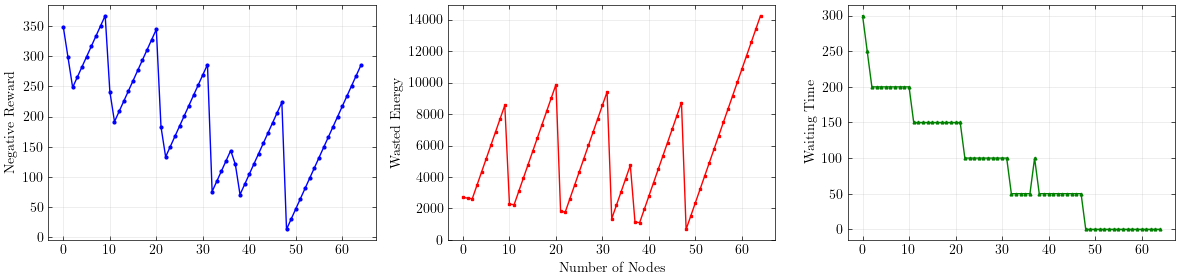

In [21]:
def extract_all_tensor_values(tensor_str):
    """Extract all three numeric values from the tuple string"""
    matches = re.findall(r'tensor\(([-\d.]+)', str(tensor_str))
    if len(matches) >= 3:
        return float(matches[0]), float(matches[1]), float(matches[2])
    else:
        return float('nan'), float('nan'), float('nan')

# Load and process the data
df = pd.read_csv('output.csv')

# Extract all three values
df[['reward_value', 'wasted_energy_value', 'waiting_time_value']] = df['reward'].apply(
    lambda x: pd.Series(extract_all_tensor_values(x))
)
df['reward_value'] = df['reward_value'] * -1
# Create a single figure with 3 subplots arranged horizontally
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Plot configurations
plot_configs = [
    {'data': 'reward_value', 'color': 'blue', 'marker': 'o', 'ylabel': 'Negative Reward'},
    {'data': 'wasted_energy_value', 'color': 'red', 'marker': 's', 'ylabel': 'Wasted Energy'},
    {'data': 'waiting_time_value', 'color': 'green', 'marker': '^', 'ylabel': 'Waiting Time'}
]

for i, config in enumerate(plot_configs):
    axes[i].plot(df['num_nodes'], df[config['data']], 
                marker=config['marker'], linewidth=1, markersize=2, 
                color=config['color'])
    
    # Only set xlabel for the middle subplot
    if i == 1:
        axes[i].set_xlabel('Number of Nodes')
    else:
        axes[i].set_xlabel('')  # Remove xlabel for other subplots
    
    axes[i].set_ylabel(config['ylabel'])
    axes[i].set_xticks(range(0, 65, 10))
    axes[i].grid(True, which='major', linestyle='-', alpha=0.3)
    axes[i].minorticks_off()
    # Title removed

# Adjust layout and save
plt.tight_layout()
plt.savefig('workshop_figures/all_metrics_vs_nn.png', dpi=300)
plt.show()